In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import os, glob

In [80]:
basin_df = pd.read_excel(r"J:\new_folder2\basin_attributes.xlsx",index_col=0) # area in km2
basin_df.dropna(inplace=True)

In [170]:
basin_df['runoff_m3'] = basin_df['runoff_dep'] * basin_df['area'] *1000
basin_df

,name_1,area,runoff_dep,abbre,runoff_m3
ID,,,,,
20,大山口,18649.9,164,dsk,3.058584e+09
22,协合拉,12940.8,353,xhl,4.568102e+09
23,沙里桂兰克,19270.4,133,slglk,2.562963e+09
26,卡群,46986.1,138,kq,6.484082e+09
28,乌鲁瓦提,21362.0,103,wlwt,2.200286e+09
29,同古孜洛克,14813.2,145,tgzlk,2.147914e+09


dsk date
1980-12-31    0.082791
1981-12-31    0.077916
1982-12-31    0.068772
1983-12-31    0.082622
1984-12-31    0.078562
1985-12-31    0.080208
1986-12-31    0.080371
1987-12-31    0.083746
1988-12-31    0.088011
1989-12-31    0.076970
1990-12-31    0.089627
1991-12-31    0.073411
1992-12-31    0.074455
1993-12-31    0.071536
1994-12-31    0.090099
1995-12-31    0.089256
1996-12-31    0.064707
1997-12-31    0.082445
1998-12-31    0.092738
1999-12-31    0.086331
2000-12-31    0.071351
2001-12-31    0.075634
2002-12-31    0.076096
2003-12-31    0.078852
2004-12-31    0.068853
2005-12-31    0.075617
2006-12-31    0.086415
2007-12-31    0.080144
2008-12-31    0.082743
2009-12-31    0.079625
2010-12-31    0.078215
2011-12-31    0.082277
2012-12-31    0.090689
2013-12-31    0.087203
2014-12-31    0.093424
2015-12-31    0.091629
2016-12-31    0.095837
2017-12-31    0.100274
2018-12-31    0.101979
2019-12-31    0.105262
2020-12-31    0.101428
2021-12-31    0.102201
2022-12-31    0.107491
20

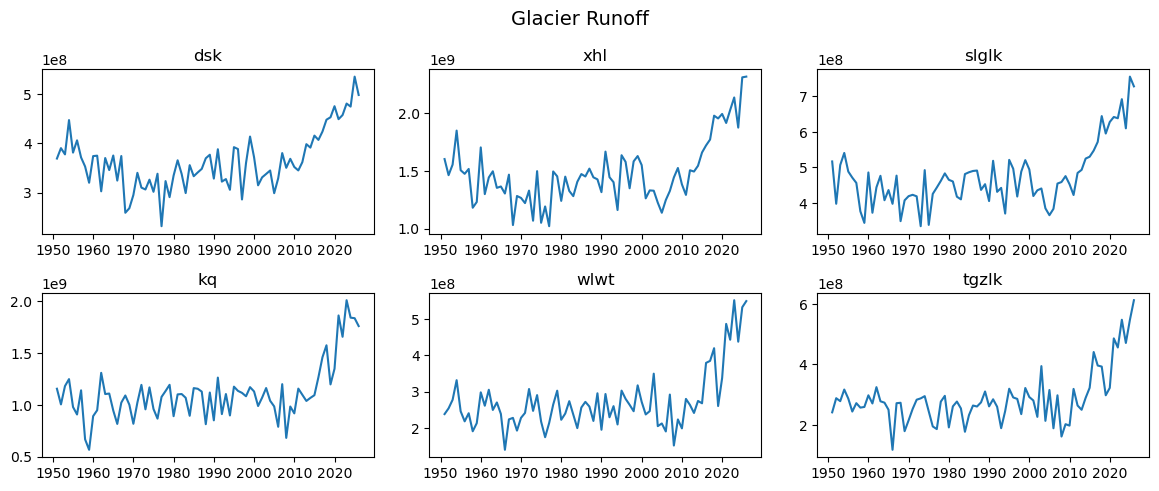

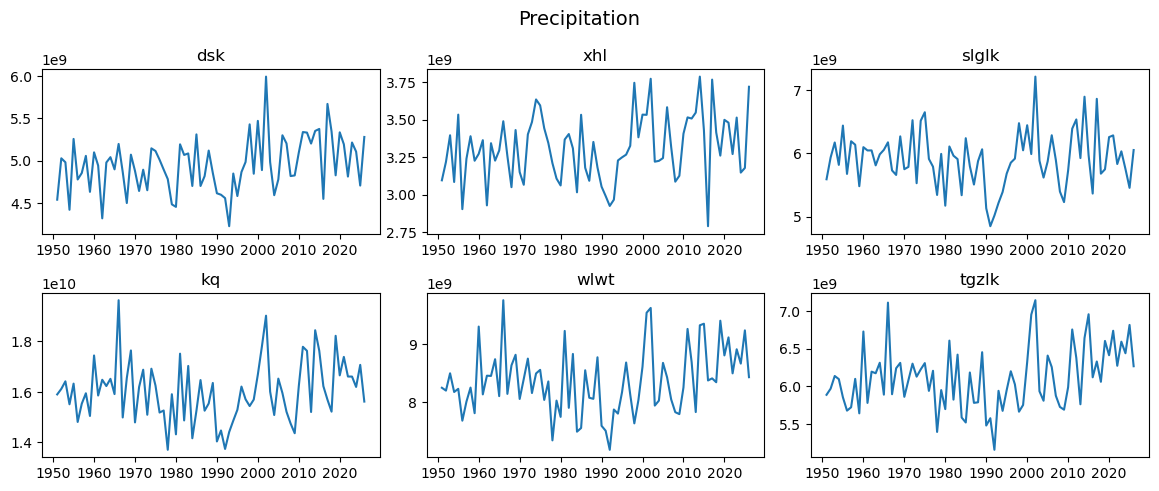

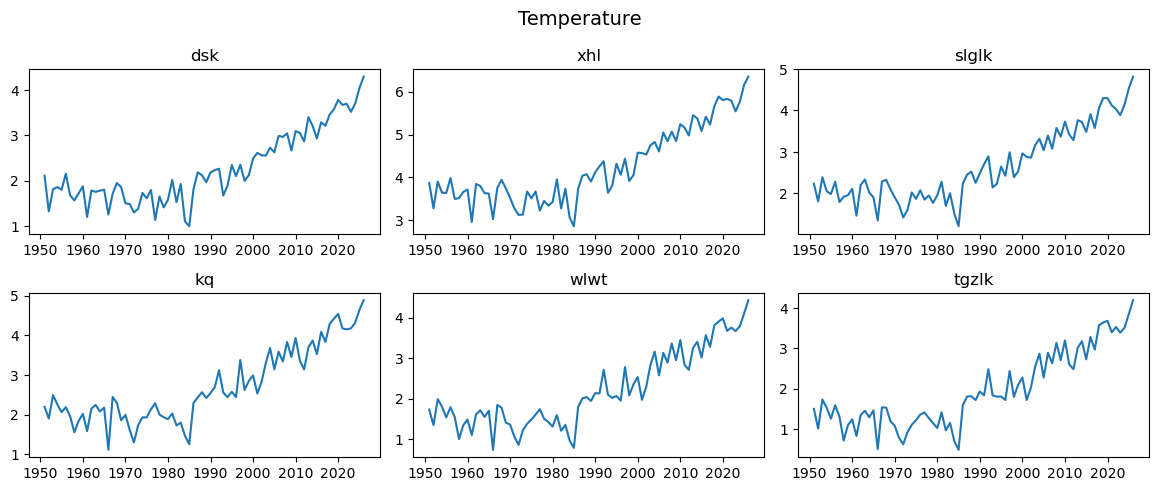

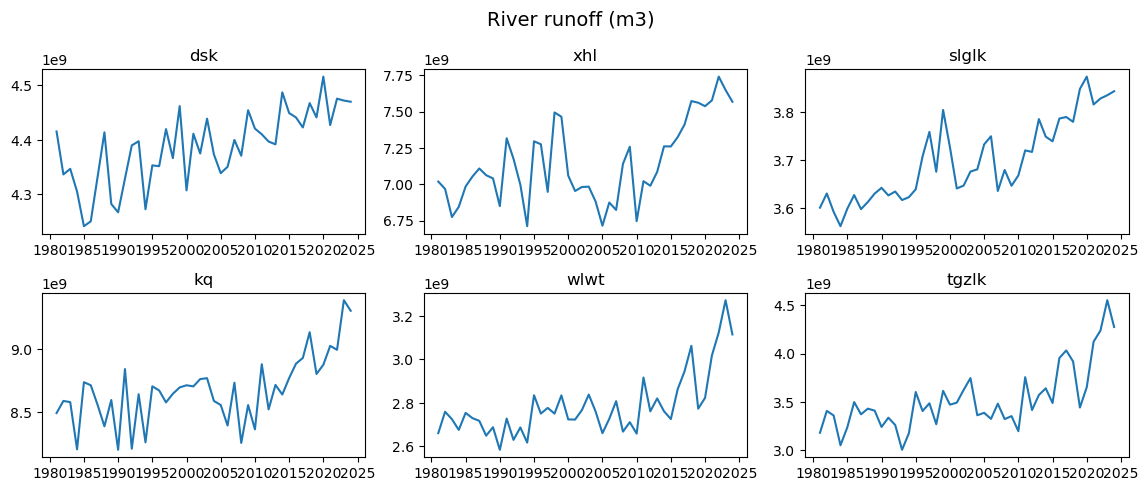

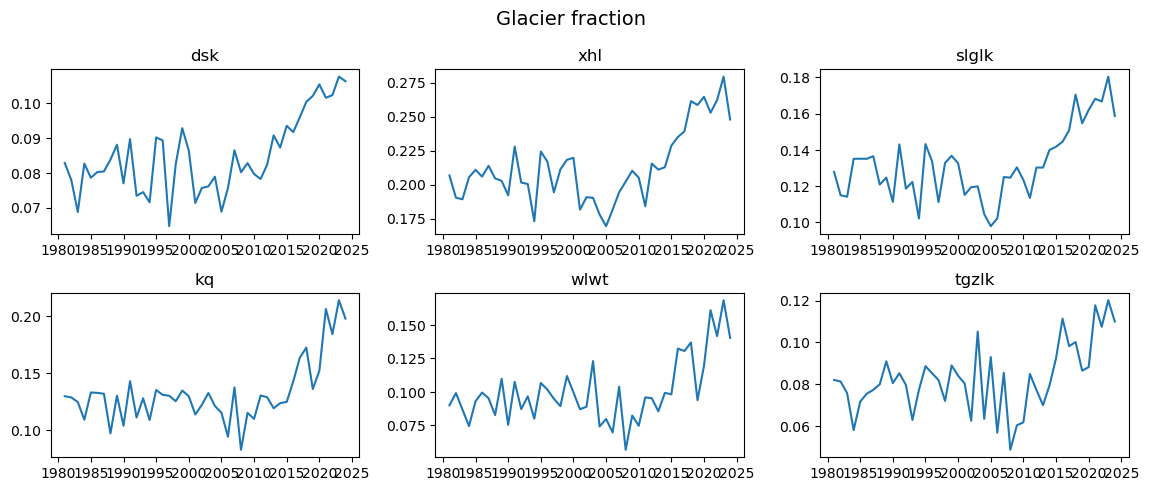

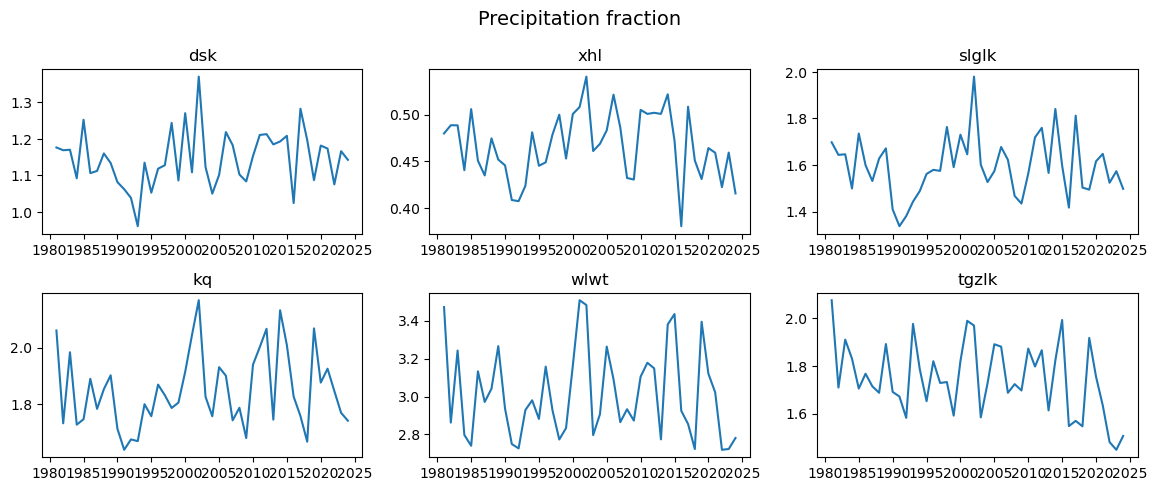

In [196]:
# Create a figure with 7 subplots
fig1, axes1 = plt.subplots(nrows=2, ncols=3, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes1 = axes1.flatten()  # Flatten for easier indexing
fig2, axes2 = plt.subplots(nrows=2, ncols=3, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes2 = axes2.flatten()  # Flatten for easier indexing
fig3, axes3 = plt.subplots(nrows=2, ncols=3, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes3 = axes3.flatten()  # Flatten for easier indexing
fig4, axes4 = plt.subplots(nrows=2, ncols=3, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes4 = axes4.flatten()  # Flatten for easier indexing
fig5, axes5 = plt.subplots(nrows=2, ncols=3, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes5 = axes5.flatten()  # Flatten for easier indexing
fig6, axes6 = plt.subplots(nrows=2, ncols=3, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes6 = axes6.flatten()  # Flatten for easier indexing
# # Remove the last unused subplot (if 7 subfigures)
# fig.delaxes(axes[-1])

for j, station in enumerate(basin_df.index):
    ax1 = axes1[j]  # Select the current subplot
    ax2 = axes2[j]
    ax3 = axes3[j]
    ax4 = axes4[j]
    ax5 = axes5[j]
    ax6 = axes6[j]

    glacier_fraction_df = pd.DataFrame()

    # list of files
    files = glob.glob(rf"J:\new_folder2\output_data\{basin_df.iloc[j].name}_r1i1p1f1_ssp370_256_16_project.csv")
    files = glob.glob(rf"J:\new_folder2\output_data\{basin_df.iloc[j].name}_*_r1i1p1f1_ssp585_256_16_project.csv")
    gcm_dfs = []
    for gcm_f in files:
        gcm_df = pd.read_csv(gcm_f, index_col=0)
        gcm_df.index = pd.to_datetime(gcm_df.index, errors="coerce")
        gcm_df = gcm_df[gcm_df.index.notna()]   # drop bad rows
        gcm_dfs.append(gcm_df)

    # stack them and take mean
    station_df = sum(gcm_dfs) / len(gcm_dfs)

    station_df.index = pd.to_datetime(station_df.index)
    station_df.dropna(subset=['glacier_runoff'], inplace=True)
    station_df['runoff'] = station_df['Projected_Runoff']*31536000/12
    station_df['prcp'] *= (1000 * basin_df.iloc[j]['area']) # Unit in m3
    # station_df['runoff'] *= (1000 * basin_df.iloc[j]['area']) # Unit in m3

    # station_runoff_df = pd.read_csv(
    #     rf"F:\geodata\river_runoff_obs\output\{j+2}_imputMF_ssp370_daily_30_fixed_mean.csv", index_col=0
    # )
    # station_runoff_df.index = pd.to_datetime(station_runoff_df.index)
    # station_runoff_df = station_runoff_df.resample('ME').mean()
    # station_df=station_runoff_df['dis_daily']
    # station_runoff_df.index = station_runoff_df.index.to_period('M').to_timestamp()
    # station_df['runoff'] *= 365.25/12 * 24 * 60 * 60


    hist_station_df  = station_df.head(76*12)

    annual_hist_station_df = hist_station_df.resample('YE').sum()
    annual_hist_station_df['tmp'] /=12 # Prcp is in mm/yr and glacier runoff is in m3/yr

    annual_hist_station_df
    ax1.plot(
        annual_hist_station_df.index,
        annual_hist_station_df[['glacier_runoff']],
    )
    ax1.set_title(f"{basin_df.iloc[j].abbre}")
    ax2.plot(
        annual_hist_station_df.index,
        annual_hist_station_df[['prcp']],
    )
    ax2.set_title(f"{basin_df.iloc[j].abbre}")
    ax3.plot(
        annual_hist_station_df.index,
        annual_hist_station_df[['tmp']] - 273.15,
    )
    ax3.set_title(f"{basin_df.iloc[j].abbre}")

    annual_hist_station_df = hist_station_df.dropna().resample('YE').sum()
    ax4.plot(
        annual_hist_station_df.index,
        annual_hist_station_df[['runoff']],
    )
    ax4.set_title(f"{basin_df.iloc[j].abbre}")
    ax5.plot(
        annual_hist_station_df.index,
        annual_hist_station_df['glacier_runoff']/annual_hist_station_df['runoff'],
    )
    ax5.set_title(f"{basin_df.iloc[j].abbre}")
    ax6.plot(
        annual_hist_station_df.index,
        annual_hist_station_df['prcp']/annual_hist_station_df['runoff'],
    )
    ax6.set_title(f"{basin_df.iloc[j].abbre}")

    print(basin_df.iloc[j].abbre,annual_hist_station_df['glacier_runoff']/annual_hist_station_df['runoff'])

# 2. Hide the 8th subplot if you only have 7 stations
if len(basin_df) < len(axes1):
    axes1[-1].axis('off')
    axes2[-1].axis('off')
    axes3[-1].axis('off')
    axes4[-1].axis('off')
    axes5[-1].axis('off')
    axes6[-1].axis('off')

fig1.suptitle("Glacier Runoff", fontsize=14)
fig2.suptitle("Precipitation", fontsize=14)
fig3.suptitle("Temperature", fontsize=14)
fig4.suptitle("River runoff (m3)", fontsize=14)
fig5.suptitle("Glacier fraction", fontsize=14)
fig6.suptitle("Precipitation fraction", fontsize=14)

# Adjust layout to prevent overlapping
fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()
fig5.tight_layout()
fig6.tight_layout()

In [195]:
files

[]

In [191]:
station_df

,prcp,tmp,runoff,ET,glacier_runoff
date,,,,,
1950-01-01,3.854070e+08,254.917020,NaN,NaN,-3.421585e-05
1950-02-01,2.736130e+08,256.736227,NaN,NaN,8.042563e+01
1950-03-01,1.835355e+08,266.059528,NaN,NaN,8.549010e+02
1950-04-01,3.062388e+08,276.666656,NaN,NaN,7.457376e+04
1950-05-01,4.180905e+08,285.002097,NaN,NaN,1.028504e+05
...,...,...,...,...,...
2100-08-01,5.831830e+08,297.401678,NaN,NaN,1.523298e+09
2100-09-01,5.143693e+08,291.349069,NaN,NaN,2.043335e+08
2100-10-01,6.482560e+08,282.482339,NaN,NaN,1.887738e+05


In [165]:
hist_station_df

,prcp,tmp,runoff,ET,glacier_runoff
date,,,,,
1950-01-01,26.017807,254.917020,NaN,NaN,-3.421585e-05
1950-02-01,18.470891,256.736227,NaN,NaN,8.042563e+01
1950-03-01,12.389997,266.059528,NaN,NaN,8.549010e+02
1950-04-01,20.673375,276.666656,NaN,NaN,7.457376e+04
1950-05-01,28.224187,285.002097,NaN,NaN,1.028504e+05
...,...,...,...,...,...
2025-08-01,55.096179,290.910376,NaN,NaN,3.461579e+08
2025-09-01,35.393309,286.202612,NaN,NaN,4.361089e+06
2025-10-01,41.820415,278.805972,NaN,NaN,0.000000e+00


In [181]:
annual_hist_station_df

,prcp,tmp,runoff,ET,glacier_runoff
date,,,,,
1980-12-31,445.962881,3294.711664,1.733028e+09,124.660655,2.608227e+08
1981-12-31,393.266916,3289.380753,2.483690e+09,130.901123,2.767792e+08
1982-12-31,433.443527,3291.589796,2.158881e+09,119.682070,2.540273e+08
1983-12-31,377.289960,3286.163029,1.819508e+09,111.101609,1.768651e+08
1984-12-31,372.850821,3283.595175,2.360519e+09,142.724023,2.318811e+08
1985-12-31,417.502405,3296.846330,2.245510e+09,118.006490,2.636447e+08
1986-12-31,390.385365,3299.433481,2.169561e+09,122.543725,2.604319e+08
1987-12-31,390.883124,3299.525092,1.644429e+09,138.330670,2.740832e+08
1988-12-31,435.612792,3298.378923,2.259490e+09,139.425309,3.100822e+08


In [162]:
station_df['runoff'] = station_runoff_df['dis_daily']

In [163]:
station_df

,prcp,tmp,runoff,ET,glacier_runoff
date,,,,,
1950-01-01,26.017807,254.917020,NaN,NaN,-3.421585e-05
1950-02-01,18.470891,256.736227,NaN,NaN,8.042563e+01
1950-03-01,12.389997,266.059528,NaN,NaN,8.549010e+02
1950-04-01,20.673375,276.666656,NaN,NaN,7.457376e+04
1950-05-01,28.224187,285.002097,NaN,NaN,1.028504e+05
...,...,...,...,...,...
2100-08-01,39.369146,297.401678,NaN,NaN,1.523298e+09
2100-09-01,34.723713,291.349069,NaN,NaN,2.043335e+08
2100-10-01,43.762050,282.482339,NaN,NaN,1.887738e+05


In [129]:
annual_hist_station_df[['glacier_runoff']]

,glacier_runoff
date,
1980-12-31,2.608227e+08
1981-12-31,2.767792e+08
1982-12-31,2.540273e+08
1983-12-31,1.768651e+08
1984-12-31,2.318811e+08
1985-12-31,2.636447e+08
1986-12-31,2.604319e+08
1987-12-31,2.740832e+08
1988-12-31,3.100822e+08


In [139]:
annual_hist_station_df[['runoff']]

,runoff
date,
1980-12-31,1.546418e+10
1981-12-31,1.873759e+10
1982-12-31,1.816692e+10
1983-12-31,2.063780e+10
1984-12-31,1.842364e+10
1985-12-31,1.679274e+10
1986-12-31,1.627799e+10
1987-12-31,1.313389e+10
1988-12-31,2.019135e+10


In [132]:
annual_hist_station_df['glacier_runoff']/annual_hist_station_df['runoff']

date
1980-12-31    0.026700
1981-12-31    0.019770
1982-12-31    0.020875
1983-12-31    0.017245
1984-12-31    0.017427
1985-12-31    0.020830
1986-12-31    0.021296
1987-12-31    0.029569
1988-12-31    0.024347
1989-12-31    0.031735
1990-12-31    0.021249
1991-12-31    0.020339
1992-12-31    0.020163
1993-12-31    0.032326
1994-12-31    0.018065
1995-12-31    0.027794
1996-12-31    0.022302
1997-12-31    0.023837
1998-12-31    0.025901
1999-12-31    0.023144
2000-12-31    0.024278
2001-12-31    0.014949
2002-12-31    0.029897
2003-12-31    0.018648
2004-12-31    0.032983
2005-12-31    0.014436
2006-12-31    0.018178
2007-12-31    0.014833
2008-12-31    0.018428
2009-12-31    0.021060
2010-12-31    0.018757
2011-12-31    0.021530
2012-12-31    0.015732
2013-12-31    0.016414
2014-12-31    0.026334
2015-12-31    0.018437
2016-12-31    0.015055
2017-12-31    0.029494
2018-12-31    0.019557
2019-12-31    0.026396
2020-12-31    0.031056
2021-12-31    0.025326
2022-12-31    0.017715
Freq: 

In [83]:
gcms = [os.path.basename(f).split("_")[1] for f in files]
gcms

['canesm5',
 'cnrm-cm6-1',
 'cnrm-esm2-1',
 'ec-earth3',
 'gfdl-esm4',
 'ipsl-cm6a-lr',
 'miroc6',
 'mpi-esm1-2-hr',
 'mri-esm2-0',
 'ukesm1-0-ll']

In [84]:
hist_station_df_reg = hist_station_df[['runoff', 'glacier_runoff', 'prcp', 'tmp']].dropna()
hist_station_df_reg['tmp'] = hist_station_df_reg['tmp'] - 273.15


In [85]:
from sklearn.preprocessing import StandardScaler

X = hist_station_df_reg[['tmp', 'prcp']]
y = hist_station_df_reg['glacier_runoff']

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
y_std = (y - y.mean()) / y.std()


In [87]:
import statsmodels.api as sm

X_std = sm.add_constant(X_std)
model = sm.OLS(y_std, X_std).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         glacier_runoff   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     181.0
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           1.46e-64
Time:                        18:44:08   Log-Likelihood:                -890.57
No. Observations:                 732   AIC:                             1787.
Df Residuals:                     729   BIC:                             1801.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.776e-17      0.030   9.17e-16      1.000      -0.059       0.059
x1             0.2935      0.043      6.871      0.000       0.210       0.377
x2             0.3296      0.043      7.715      0.000       0.246       0.413
==============================================================================
Omnibus:                      254.362   Durbin-Watson:                   1.796
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              834.446
Skew:                           1.676   Prob(JB):                    6.34e-182
Kurtosis:                       7.016   Cond. No.                         2.41
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

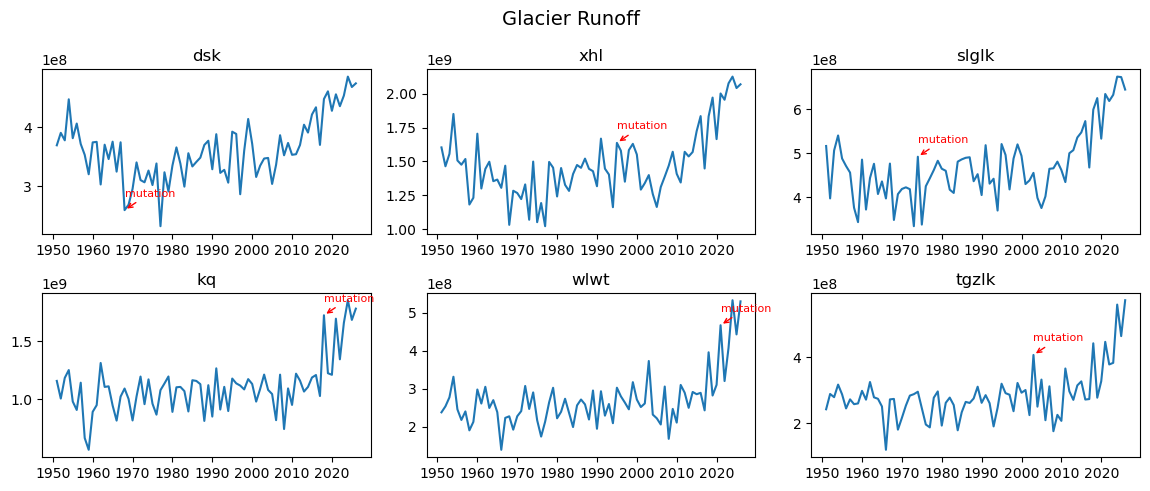

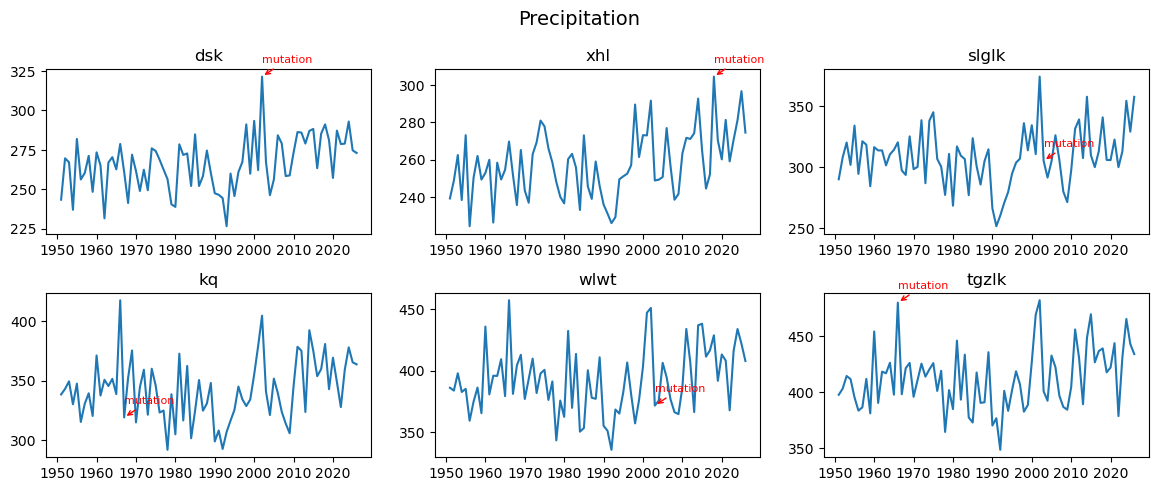

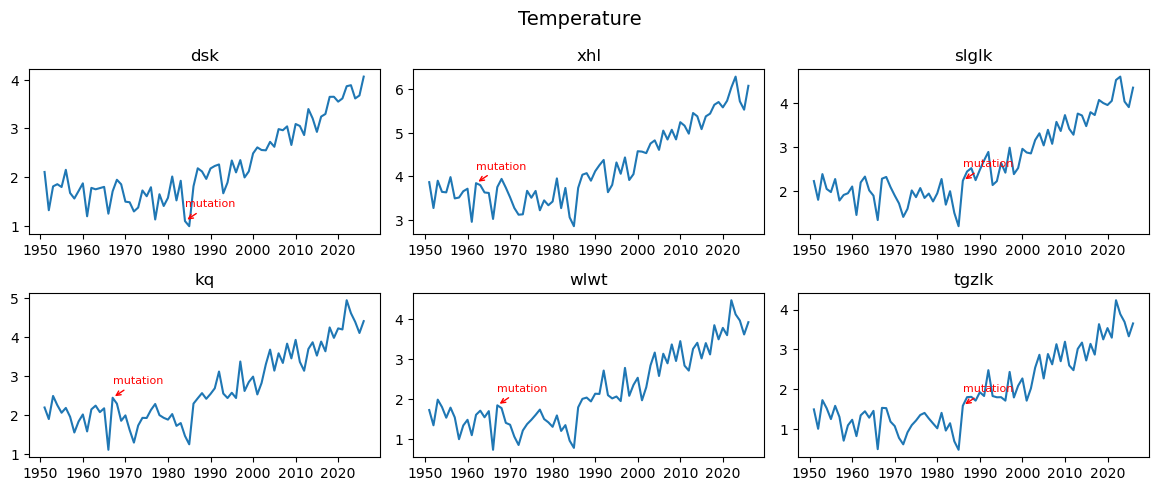

In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import glob

# Create three figures for glacier runoff, precipitation, temperature
fig1, axes1 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes1 = axes1.flatten()
fig2, axes2 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes2 = axes2.flatten()
fig3, axes3 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes3 = axes3.flatten()

for j, station in enumerate(basin_df.index):
    ax1, ax2, ax3 = axes1[j], axes2[j], axes3[j]

    # collect all GCM files for this station
    files = glob.glob(rf"J:\new_folder2\input_data\{basin_df.iloc[j].name}_*_ssp370_future.csv")
    gcm_dfs = []
    for gcm_f in files:
        gcm_df = pd.read_csv(gcm_f, index_col=0)
        gcm_df.index = pd.to_datetime(gcm_df.index, errors="coerce")
        gcm_df = gcm_df[gcm_df.index.notna()]
        gcm_dfs.append(gcm_df)

    # multi-model mean
    station_df = sum(gcm_dfs) / len(gcm_dfs)

    # historical slice
    station_df.dropna(subset=['glacier_runoff'], inplace=True)
    hist_station_df = station_df.head(76*12)

    # annual aggregation
    annual_hist_station_df = hist_station_df.resample('YE').sum()
    annual_hist_station_df['tmp'] /= 12  # convert monthly mean to annual mean
    annual_hist_station_df['tmp'] -= 273.15

    # plotting
    ax1.plot(annual_hist_station_df.index, annual_hist_station_df['glacier_runoff'])
    ax1.set_title(f"{basin_df.iloc[j].abbre}")

    ax2.plot(annual_hist_station_df.index, annual_hist_station_df['prcp'])
    ax2.set_title(f"{basin_df.iloc[j].abbre}")

    ax3.plot(annual_hist_station_df.index, annual_hist_station_df['tmp'])
    ax3.set_title(f"{basin_df.iloc[j].abbre}")

    # --- mutation site detection and annotation ---
    for col, ax in zip(['glacier_runoff', 'prcp', 'tmp'], [ax1, ax2, ax3]):
        diffs = annual_hist_station_df[col].diff()
        threshold = diffs.abs().quantile(0.99)  # top 1% largest changes
        mutation_points = diffs[diffs.abs() > threshold].index

        for mp in mutation_points:
            ax.annotate("mutation",
                        xy=(mp, annual_hist_station_df.loc[mp, col]),
                        xytext=(0, 10), textcoords="offset points",
                        arrowprops=dict(arrowstyle="->", color="red"),
                        fontsize=8, color="red")

# hide unused subplot if fewer than 7 stations
if len(basin_df) < len(axes1):
    axes1[-1].axis('off')
    axes2[-1].axis('off')
    axes3[-1].axis('off')

# figure titles
fig1.suptitle("Glacier Runoff", fontsize=14)
fig2.suptitle("Precipitation", fontsize=14)
fig3.suptitle("Temperature", fontsize=14)

# layout
fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()

plt.show()


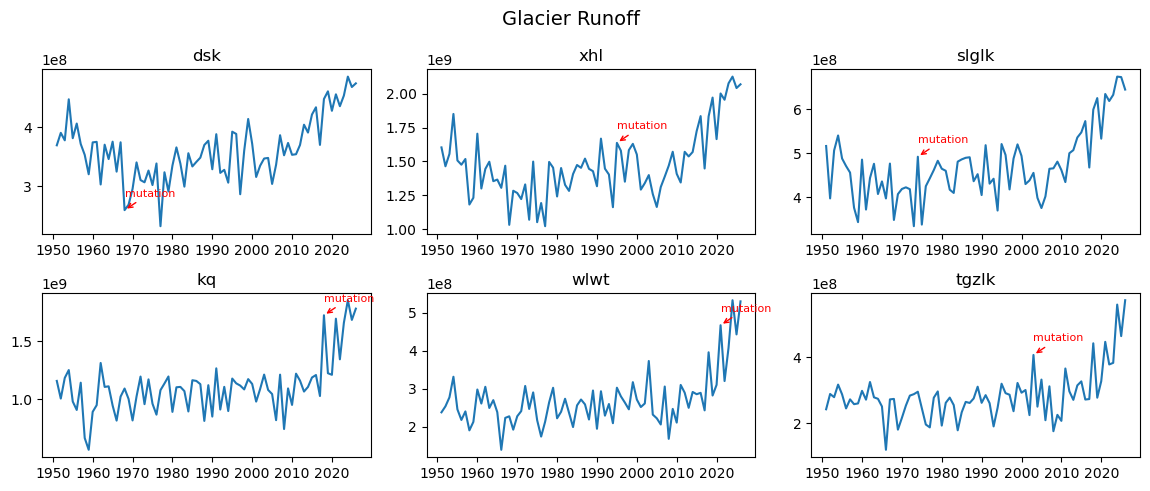

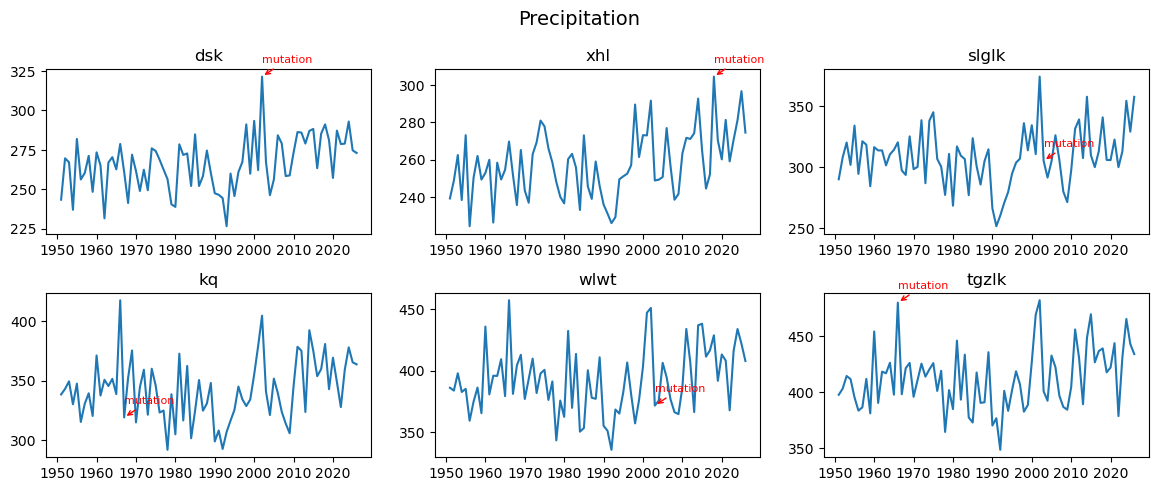

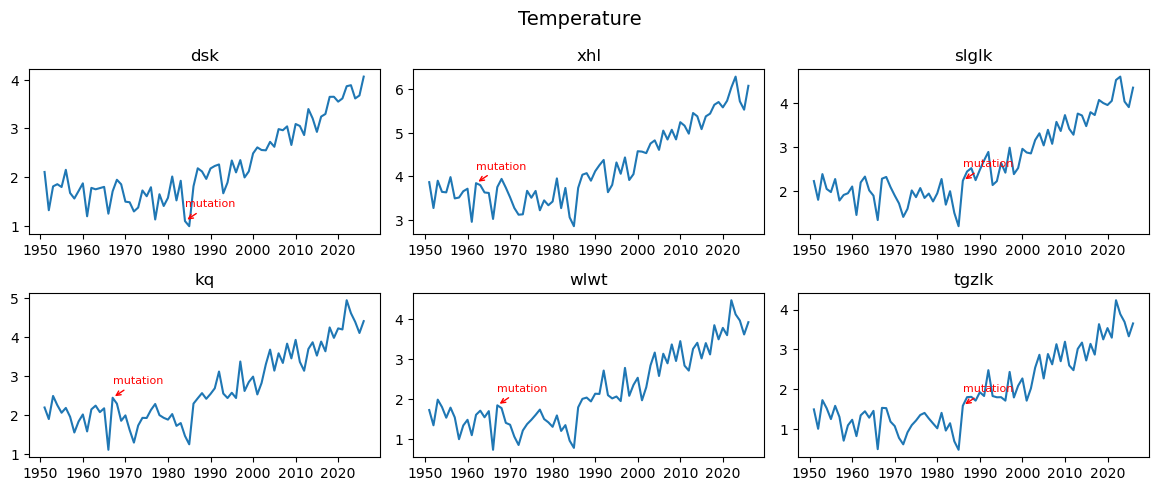

In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import glob

# Create three figures for glacier runoff, precipitation, temperature
fig1, axes1 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes1 = axes1.flatten()
fig2, axes2 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes2 = axes2.flatten()
fig3, axes3 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes3 = axes3.flatten()

for j, station in enumerate(basin_df.index):
    ax1, ax2, ax3 = axes1[j], axes2[j], axes3[j]

    # collect all GCM files for this station
    files = glob.glob(rf"J:\new_folder2\input_data\{basin_df.iloc[j].name}_*_ssp370_future.csv")
    gcm_dfs = []
    for gcm_f in files:
        gcm_df = pd.read_csv(gcm_f, index_col=0)
        gcm_df.index = pd.to_datetime(gcm_df.index, errors="coerce")
        gcm_df = gcm_df[gcm_df.index.notna()]
        gcm_dfs.append(gcm_df)

    # multi-model mean
    station_df = sum(gcm_dfs) / len(gcm_dfs)

    # historical slice
    station_df.dropna(subset=['glacier_runoff'], inplace=True)
    hist_station_df = station_df.head(76*12)

    # annual aggregation
    annual_hist_station_df = hist_station_df.resample('YE').sum()
    annual_hist_station_df['tmp'] /= 12  # convert monthly mean to annual mean
    annual_hist_station_df['tmp'] -= 273.15

    # plotting
    ax1.plot(annual_hist_station_df.index, annual_hist_station_df['glacier_runoff'])
    ax1.set_title(f"{basin_df.iloc[j].abbre}")

    ax2.plot(annual_hist_station_df.index, annual_hist_station_df['prcp'])
    ax2.set_title(f"{basin_df.iloc[j].abbre}")

    ax3.plot(annual_hist_station_df.index, annual_hist_station_df['tmp'])
    ax3.set_title(f"{basin_df.iloc[j].abbre}")

    # --- mutation site detection and annotation ---
    for col, ax in zip(['glacier_runoff', 'prcp', 'tmp'], [ax1, ax2, ax3]):
        diffs = annual_hist_station_df[col].diff()
        threshold = diffs.abs().quantile(0.99)  # top 1% largest changes
        mutation_points = diffs[diffs.abs() > threshold].index

        for mp in mutation_points:
            ax.annotate("mutation",
                        xy=(mp, annual_hist_station_df.loc[mp, col]),
                        xytext=(0, 10), textcoords="offset points",
                        arrowprops=dict(arrowstyle="->", color="red"),
                        fontsize=8, color="red")

# hide unused subplot if fewer than 7 stations
if len(basin_df) < len(axes1):
    axes1[-1].axis('off')
    axes2[-1].axis('off')
    axes3[-1].axis('off')

# figure titles
fig1.suptitle("Glacier Runoff", fontsize=14)
fig2.suptitle("Precipitation", fontsize=14)
fig3.suptitle("Temperature", fontsize=14)

# layout
fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()

plt.show()


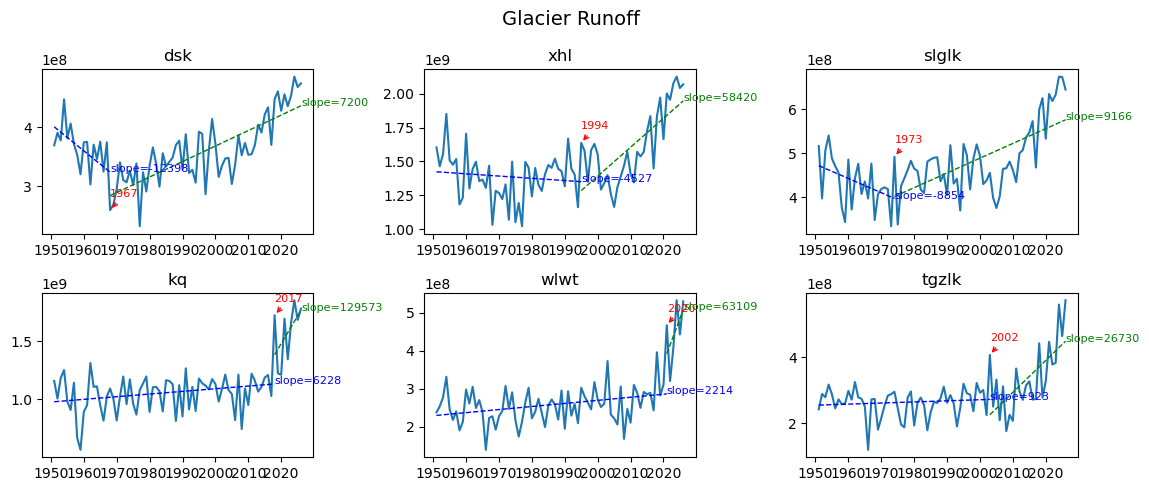

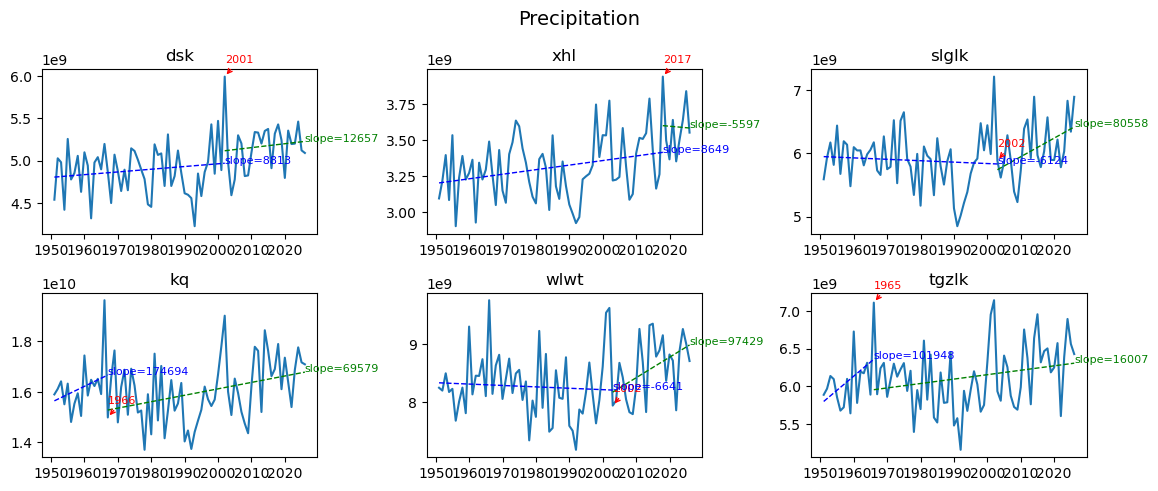

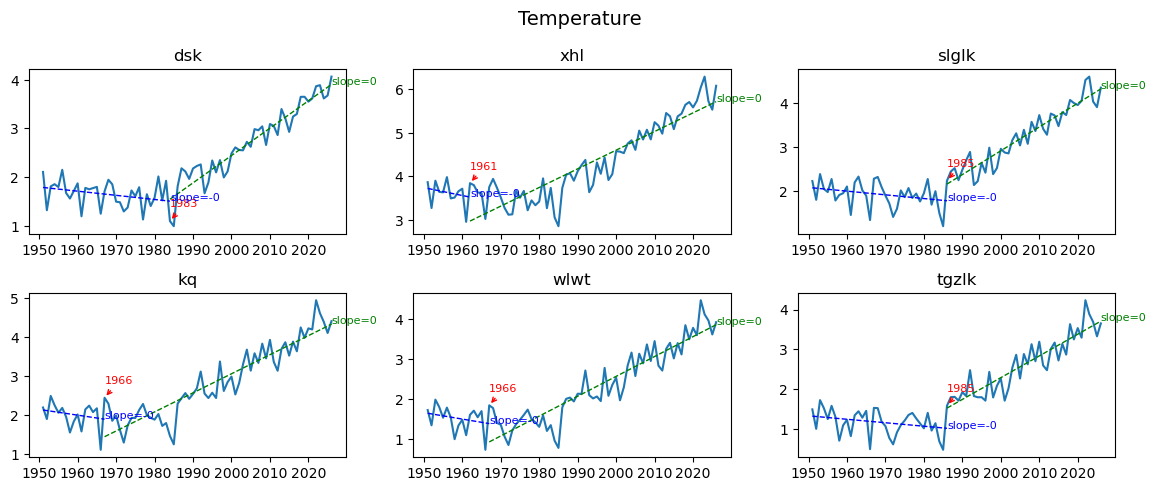

In [186]:
import matplotlib.pyplot as plt
import pandas as pd
import glob

# Create three figures for glacier runoff, precipitation, temperature
fig1, axes1 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes1 = axes1.flatten()
fig2, axes2 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes2 = axes2.flatten()
fig3, axes3 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes3 = axes3.flatten()

for j, station in enumerate(basin_df.index):
    ax1, ax2, ax3 = axes1[j], axes2[j], axes3[j]

    # collect all GCM files for this station
    files = glob.glob(rf"J:\new_folder2\input_data\{basin_df.iloc[j].name}_*_ssp370_future.csv")
    gcm_dfs = []
    for gcm_f in files:
        gcm_df = pd.read_csv(gcm_f, index_col=0)
        gcm_df.index = pd.to_datetime(gcm_df.index, errors="coerce")
        gcm_df = gcm_df[gcm_df.index.notna()]
        gcm_dfs.append(gcm_df)

    # multi-model mean
    station_df = sum(gcm_dfs) / len(gcm_dfs)

    # historical slice
    station_df.dropna(subset=['glacier_runoff'], inplace=True)
    station_df['runoff'] *= 31536000/12
    station_df['prcp'] *= (1000 * basin_df.iloc[j]['area']) # Unit in m3
    hist_station_df = station_df.head(76*12)

    # annual aggregation
    annual_hist_station_df = hist_station_df.resample('YE').sum()
    annual_hist_station_df['tmp'] /= 12  # convert monthly mean to annual mean
    annual_hist_station_df['tmp'] -= 273.15

    annual_hist_station_df['glacier_runoff_fraction'] = annual_hist_station_df['glacier_runoff']

    # plotting
    ax1.plot(annual_hist_station_df.index, annual_hist_station_df['glacier_runoff'])
    ax1.set_title(f"{basin_df.iloc[j].abbre}")

    ax2.plot(annual_hist_station_df.index, annual_hist_station_df['prcp'])
    ax2.set_title(f"{basin_df.iloc[j].abbre}")

    ax3.plot(annual_hist_station_df.index, annual_hist_station_df['tmp'])
    ax3.set_title(f"{basin_df.iloc[j].abbre}")

    for col, ax in zip(['glacier_runoff', 'prcp', 'tmp'], [ax1, ax2, ax3]):
        diffs = annual_hist_station_df[col].diff()
        threshold = diffs.abs().quantile(0.99)  # top 1% largest changes
        mutation_points = diffs[diffs.abs() > threshold].index

        for mp in mutation_points:
            ax.annotate(int(mutation_points.year[0]),
                        xy=(mp, annual_hist_station_df.loc[mp, col]),
                        xytext=(0, 10), textcoords="offset points",
                        arrowprops=dict(arrowstyle="->", color="red"),
                        fontsize=8, color="red")

            # convert datetime index to numeric (ordinal)
            x = annual_hist_station_df.index.map(pd.Timestamp.toordinal)
            y = annual_hist_station_df[col].values

            mask_before = annual_hist_station_df.index <= mp
            mask_after = annual_hist_station_df.index >= mp

            # fit line before
            if mask_before.sum() > 2:
                coeffs = np.polyfit(x[mask_before], y[mask_before], 1)
                slope = coeffs[0]
                fit_before = np.polyval(coeffs, x[mask_before])
                ax.plot(annual_hist_station_df.index[mask_before], fit_before,
                        color="blue", linestyle="--", linewidth=1)
                # annotate slope
                ax.text(annual_hist_station_df.index[mask_before][-1],
                        fit_before[-1],
                        f"slope={slope:.0f}",
                        color="blue", fontsize=8)

        # fit line after
        if mask_after.sum() > 2:
            coeffs = np.polyfit(x[mask_after], y[mask_after], 1)
            slope = coeffs[0]
            fit_after = np.polyval(coeffs, x[mask_after])
            ax.plot(annual_hist_station_df.index[mask_after], fit_after,
                    color="green", linestyle="--", linewidth=1)
            # annotate slope
            ax.text(annual_hist_station_df.index[mask_after][-1],
                    fit_after[-1],
                    f"slope={slope:.0f}",
                    color="green", fontsize=8)


    # hide unused subplot if fewer than 7 stations
    if len(basin_df) < len(axes1):
        axes1[-1].axis('off')
        axes2[-1].axis('off')
        axes3[-1].axis('off')

# figure titles
fig1.suptitle("Glacier Runoff", fontsize=14)
fig2.suptitle("Precipitation", fontsize=14)
fig3.suptitle("Temperature", fontsize=14)

# layout
fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()

plt.show()


dsk -2.7265828006979257e-06 before
dsk 1.6088583392383791e-06 after
dsk 13959.204698686075 before
dsk -121979.46866012539 after
dsk -2.334222148249515e-05 before
dsk 0.00015547582284605897 after
xhl -4.6584031943403875e-06 before
xhl 3.6289159851720993e-06 after
xhl 7210.867320891897 before
xhl -46665.49994965238 after
xhl -4.932201669637716e-05 before
xhl 0.00011817871401056212 after
slglk -2.0933622400279156e-06 before
slglk 2.2876669350847365e-06 after
slglk 2541.019872066609 before
slglk -165395.27446315126 after
slglk -2.302722376050301e-05 before
slglk 0.0001538223769992738 after
kq 1.3285384955464187e-07 before
kq 1.692358970546195e-05 after
kq 174694.25700680612 before
kq 54316.546120133185 after
kq -4.0115037696692676e-05 before
kq 0.00013689641342052696 after
wlwt 2.309355381841984e-07 before
wlwt 1.2616038537002759e-05 after
wlwt -6641.261518383101 before
wlwt 100082.9189378444 after
wlwt -4.401111720599121e-05 before
wlwt 0.00013808365986130655 after
tgzlk -1.54929753546973

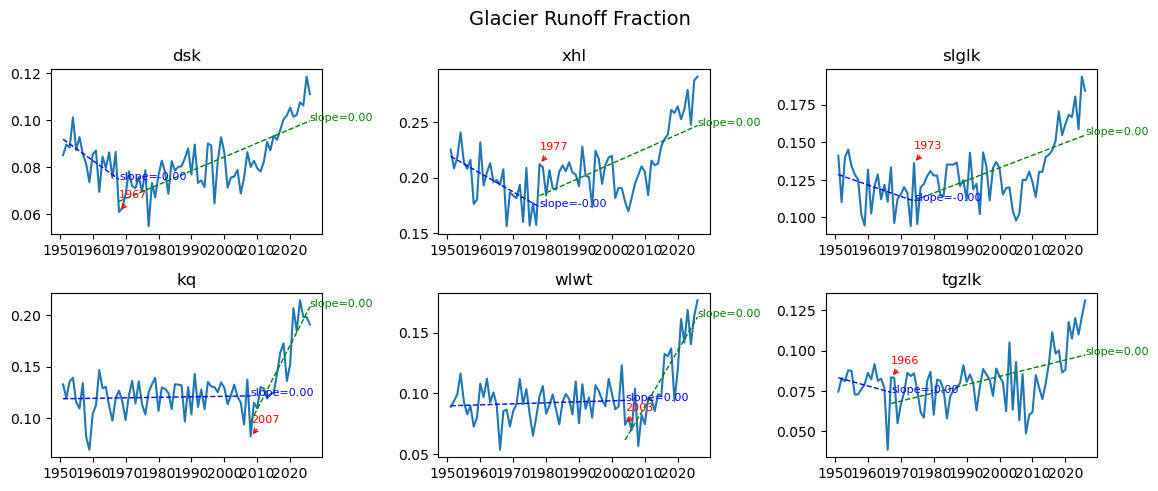

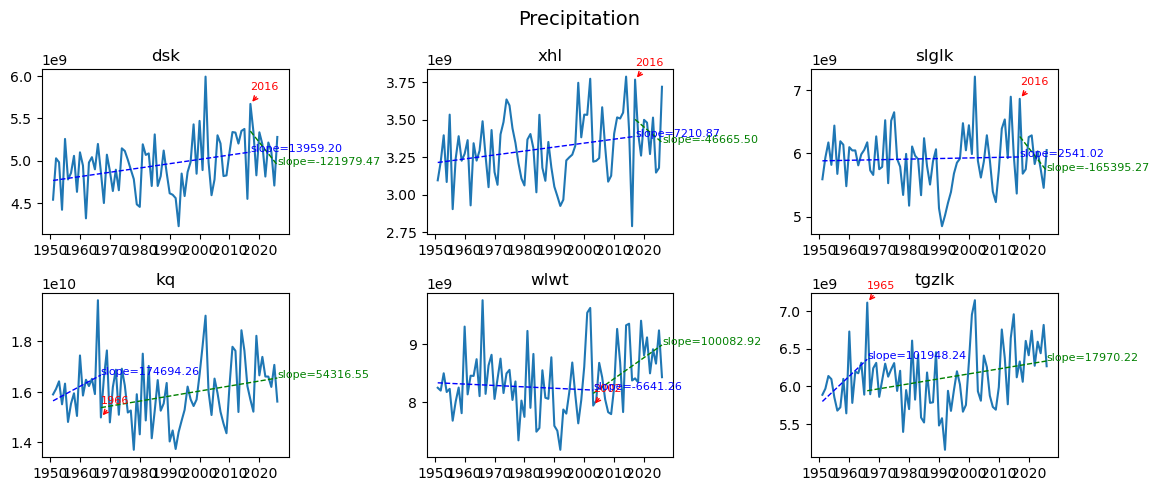

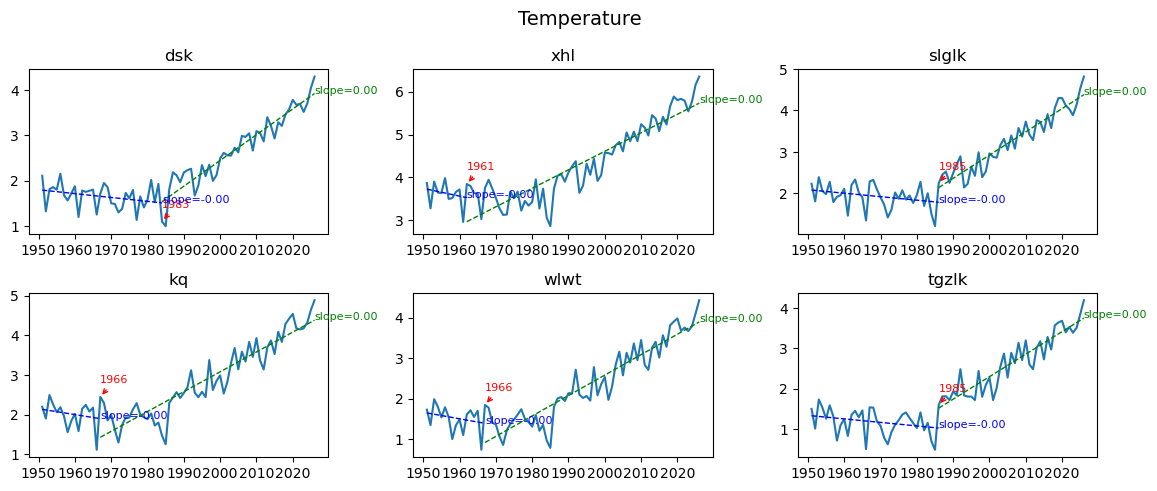

In [207]:
import matplotlib.pyplot as plt
import pandas as pd
import glob

# Create three figures for glacier runoff, precipitation, temperature
fig1, axes1 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes1 = axes1.flatten()
fig2, axes2 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes2 = axes2.flatten()
fig3, axes3 = plt.subplots(2, 3, figsize=(11.69, 8.27 * 0.6))
axes3 = axes3.flatten()

for j, station in enumerate(basin_df.index):
    ax1, ax2, ax3 = axes1[j], axes2[j], axes3[j]

    # collect all GCM files for this station
    files = glob.glob(rf"J:\new_folder2\output_data\{basin_df.iloc[j].name}_*_r1i1p1f1_ssp585_256_16_project.csv")
    gcm_dfs = []
    for gcm_f in files:
        gcm_df = pd.read_csv(gcm_f, index_col=0)
        gcm_df.index = pd.to_datetime(gcm_df.index, errors="coerce")
        gcm_df = gcm_df[gcm_df.index.notna()]
        gcm_dfs.append(gcm_df)

    # multi-model mean
    station_df = sum(gcm_dfs) / len(gcm_dfs)

    # historical slice
    station_df.dropna(subset=['glacier_runoff'], inplace=True)
    station_df['runoff'] = station_df['Projected_Runoff'] * 31536000/12
    station_df['prcp'] *= (1000 * basin_df.iloc[j]['area']) # Unit in m3
    hist_station_df = station_df.head(76*12)

    # annual aggregation
    annual_hist_station_df = hist_station_df.resample('YE').sum()
    annual_hist_station_df['tmp'] /= 12  # convert monthly mean to annual mean
    annual_hist_station_df['tmp'] -= 273.15

    annual_hist_station_df['glacier_runoff_fraction'] = annual_hist_station_df['glacier_runoff']/annual_hist_station_df['runoff']

    # plotting
    ax1.plot(annual_hist_station_df.index, annual_hist_station_df['glacier_runoff_fraction'])
    ax1.set_title(f"{basin_df.iloc[j].abbre}")

    ax2.plot(annual_hist_station_df.index, annual_hist_station_df['prcp'])
    ax2.set_title(f"{basin_df.iloc[j].abbre}")

    ax3.plot(annual_hist_station_df.index, annual_hist_station_df['tmp'])
    ax3.set_title(f"{basin_df.iloc[j].abbre}")

    for col, ax in zip(['glacier_runoff_fraction', 'prcp', 'tmp'], [ax1, ax2, ax3]):
        diffs = annual_hist_station_df[col].diff()
        threshold = diffs.abs().quantile(0.99)  # top 1% largest changes
        mutation_points = diffs[diffs.abs() > threshold].index

        for mp in mutation_points:
            ax.annotate(int(mutation_points.year[0]),
                        xy=(mp, annual_hist_station_df.loc[mp, col]),
                        xytext=(0, 10), textcoords="offset points",
                        arrowprops=dict(arrowstyle="->", color="red"),
                        fontsize=8, color="red")

            # convert datetime index to numeric (ordinal)
            x = annual_hist_station_df.index.map(pd.Timestamp.toordinal)
            y = annual_hist_station_df[col].values

            mask_before = annual_hist_station_df.index <= mp
            mask_after = annual_hist_station_df.index >= mp

            # fit line before
            if mask_before.sum() > 2:
                coeffs = np.polyfit(x[mask_before], y[mask_before], 1)
                slope = coeffs[0]
                fit_before = np.polyval(coeffs, x[mask_before])
                ax.plot(annual_hist_station_df.index[mask_before], fit_before,
                        color="blue", linestyle="--", linewidth=1)
                # annotate slope
                ax.text(annual_hist_station_df.index[mask_before][-1],
                        fit_before[-1],
                        f"slope={slope:.2f}",
                        color="blue", fontsize=8)

                print(f"{basin_df.iloc[j].abbre}",slope,'before')

        # fit line after
        if mask_after.sum() > 2:
            coeffs = np.polyfit(x[mask_after], y[mask_after], 1)
            slope = coeffs[0]
            fit_after = np.polyval(coeffs, x[mask_after])
            ax.plot(annual_hist_station_df.index[mask_after], fit_after,
                    color="green", linestyle="--", linewidth=1)
            # annotate slope
            ax.text(annual_hist_station_df.index[mask_after][-1],
                    fit_after[-1],
                    f"slope={slope:.2f}",
                    color="green", fontsize=8)
            # print(f"{basin_df.iloc[j].abbre}",slope,'after')



    # hide unused subplot if fewer than 7 stations
    if len(basin_df) < len(axes1):
        axes1[-1].axis('off')
        axes2[-1].axis('off')
        axes3[-1].axis('off')

# figure titles
fig1.suptitle("Glacier Runoff Fraction", fontsize=14)
fig2.suptitle("Precipitation", fontsize=14)
fig3.suptitle("Temperature", fontsize=14)

# layout
fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()

plt.show()
